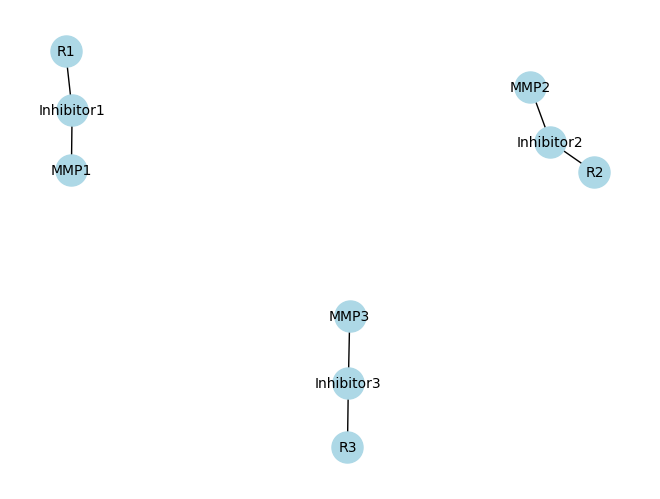

In [5]:
import rdkit
from rdkit import Chem
from rdkit.Chem import rdRGroupDecomposition
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 阻害剤とMMPのデータを準備
data = {
    'inhibitor': ['Inhibitor1', 'Inhibitor2', 'Inhibitor3'],
    'MMP': ['MMP1', 'MMP2', 'MMP3'],
    'smiles': ['CC(C)C(=O)NC1=CC=CC=C1', 'CC(C)C(=O)NC1=CC=CC=C1', 'CC(C)C(=O)NC1=CC=CC=C1']
}

df = pd.DataFrame(data)

# 分子のR分解を実行
mols = [Chem.MolFromSmiles(smiles) for smiles in df['smiles']]
core = Chem.MolFromSmarts('CC(C)C')
groups = rdRGroupDecomposition.RGroupDecompose([core], mols)

# ナレッジグラフを作成
G = nx.Graph()

# ノードの追加（阻害剤とMMP）
for _, row in df.iterrows():
    G.add_node(row['inhibitor'], label=row['inhibitor'])
    G.add_node(row['MMP'], label=row['MMP'])
    G.add_edge(row['inhibitor'], row['MMP'])

# ノードの追加（Rグループ）
for idx, group in enumerate(groups[0]):
    G.add_node(f'R{idx+1}', label=f'R{idx+1}')
    G.add_edge(df['inhibitor'][idx], f'R{idx+1}')

# ナレッジグラフを可視化
pos = nx.spring_layout(G)
labels = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', node_size=500, font_size=10)
plt.show()


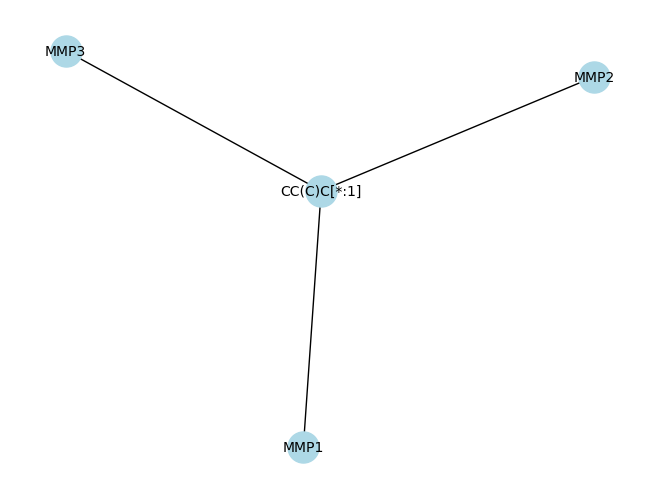

In [8]:
import rdkit
from rdkit import Chem
from rdkit.Chem import rdRGroupDecomposition
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 阻害剤とMMPのデータを準備
data = {
    'inhibitor': ['Inhibitor1', 'Inhibitor2', 'Inhibitor3'],
    'MMP': ['MMP1', 'MMP2', 'MMP3'],
    'smiles': ['CC(C)C(=O)NC1=CC=CC=C1', 'CC(C)C(=O)NC1=CC=CC=C1', 'CC(C)C(=O)NC1=CC=CC=C1']
}

df = pd.DataFrame(data)

# 分子の作成
mols = [Chem.MolFromSmiles(smiles) for smiles in df['smiles']]

# コア分子の作成
core = Chem.MolFromSmarts('CC(C)C')

# R分解の実行
if core and all(mols):
    groups, unmatched = rdRGroupDecomposition.RGroupDecompose([core], mols)

    # ナレッジグラフを作成
    G = nx.Graph()

    # ノードの追加（MMP）
    for _, row in df.iterrows():
        G.add_node(row['MMP'], label=row['MMP'])

    # ノードの追加（Rグループとコネクション）
    for idx, group in enumerate(groups):
        rgroup = group.get('Core', None)
        if rgroup:
            rgroup_label = Chem.MolToSmiles(rgroup)
            G.add_node(rgroup_label, label=rgroup_label)
            G.add_edge(df['MMP'][idx], rgroup_label)

    # ナレッジグラフを可視化
    pos = nx.spring_layout(G)
    labels = nx.get_node_attributes(G, 'label')
    nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', node_size=500, font_size=10)
    plt.show()
else:
    print("Error in molecule or core creation")
